# **CO2 Emission Case Study**

**Problem statement:\**

The Global Automotive Council aims to understand the key factors influencing vehicle CO₂ emissions and explore data-driven strategies for emission reduction.
A dataset containing detailed information on vehicle specifications, engine characteristics, fuel types, and emission levels has been provided.

The objective is to analyze this dataset to uncover hidden patterns, identify the major contributors to CO₂ emissions, and develop predictive models to support policy and design decisions in the automotive sector.

**Importing Some Important Libraries**

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold,GridSearchCV,cross_val_score
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')


# **1. Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.**


In [2]:
# loading the dataset

df = pd.read_csv("/content/CO2_Emissions.csv")

In [3]:
#check first 5 records

df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
# checking the shape of the dataset

df.shape

(7385, 12)

In [5]:
# checking for the columns names

df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')

In [6]:
# Collecting the information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [7]:
# checking for uniques entiries in each columns

df.nunique()

,0
Make,42
Model,2053
Vehicle Class,16
Engine Size(L),51
Cylinders,8
Transmission,27
Fuel Type,5
Fuel Consumption City (L/100 km),211
Fuel Consumption Hwy (L/100 km),143
Fuel Consumption Comb (L/100 km),181


# **2. Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis**

In [8]:
# checking for the Null values

df.isnull().sum()


,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


**There is no null values present in the dataset.**

In [9]:
# checking for the duplicated entiries

df.duplicated().sum()

np.int64(1103)

In [10]:
# removing the duplicated

df = df.drop_duplicates()

In [11]:
df.shape

(6282, 12)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),6282.0,3.161812,1.365201,0.9,2.0,3.0,3.7,8.4
Cylinders,6282.0,5.618911,1.846250,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),6282.0,12.610220,3.553066,4.2,10.1,12.1,14.7,30.6
Fuel Consumption Hwy (L/100 km),6282.0,9.070583,2.278884,4.0,7.5,8.7,10.3,20.6
Fuel Consumption Comb (L/100 km),6282.0,11.017876,2.946876,4.1,8.9,10.6,12.7,26.1
Fuel Consumption Comb (mpg),6282.0,27.411016,7.245318,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),6282.0,251.157752,59.290426,96.0,208.0,246.0,289.0,522.0


In [13]:
df.reset_index(drop=True, inplace=True)

In [14]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


# **3. Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.**

## **Brand of cars**

In [15]:
print(f"we have total of {len(df["Make"].unique())} Car Makes")
df_makes = df["Make"].value_counts().reset_index().rename(columns={"count":"Count"})
df_makes.head()

we have total of 42 Car Makes


,Make,Count
0,FORD,577
1,CHEVROLET,515
2,BMW,501
3,MERCEDES-BENZ,365
4,PORSCHE,296


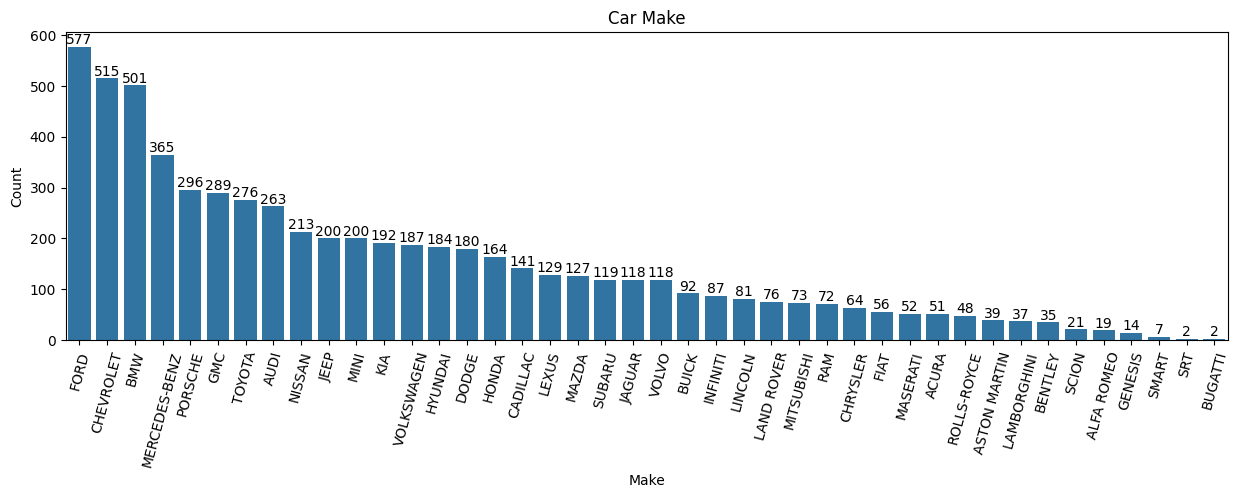

In [16]:
plt.figure(figsize=(15,4))
ax = sns.barplot(data=df_makes,x="Make",y="Count")
plt.title("Car Make")
plt.xticks(rotation = 75)
plt.xlabel("Make")
plt.ylabel("Count")
plt.bar_label(ax.containers[0])
plt.show()

## **Models of Cars**

In [17]:
print(f"we have a total of {len(df["Model"].unique())} Models of Cars")
df_models = df["Model"].value_counts().reset_index().rename(columns={"count":"Count"})[:25]
df_models.head()

we have a total of 2053 Models of Cars


,Model,Count
0,F-150 FFV,32
1,F-150 FFV 4X4,31
2,MUSTANG,27
3,FOCUS FFV,24
4,F-150 4X4,20


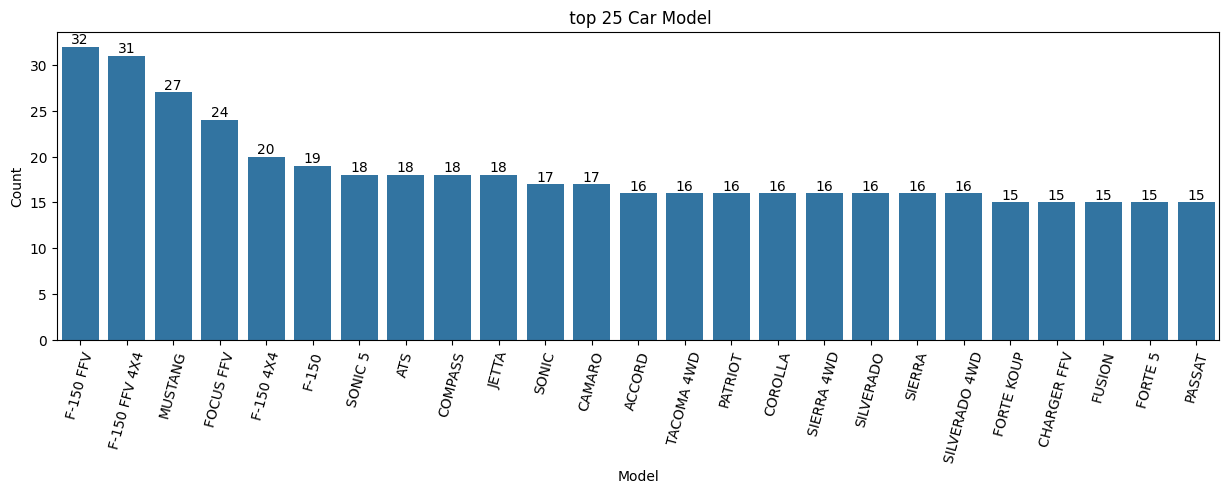

In [18]:
plt.figure(figsize=(15,4))
ax = sns.barplot(data=df_models,x="Model",y="Count")
plt.title(" top 25 Car Model")
plt.xticks(rotation = 75)
plt.xlabel("Model")
plt.ylabel("Count")
plt.bar_label(ax.containers[0])
plt.show()

## **Vehical Class**

In [19]:
print(f"we have a total of {len(df["Vehicle Class"].unique())} vehicle class")
df_vehical_class = df["Vehicle Class"].value_counts().reset_index().rename(columns={"count":"Count"})
df_vehical_class.head()

we have a total of 16 vehicle class


,Vehicle Class,Count
0,SUV - SMALL,1006
1,MID-SIZE,983
2,COMPACT,903
3,SUV - STANDARD,613
4,SUBCOMPACT,533


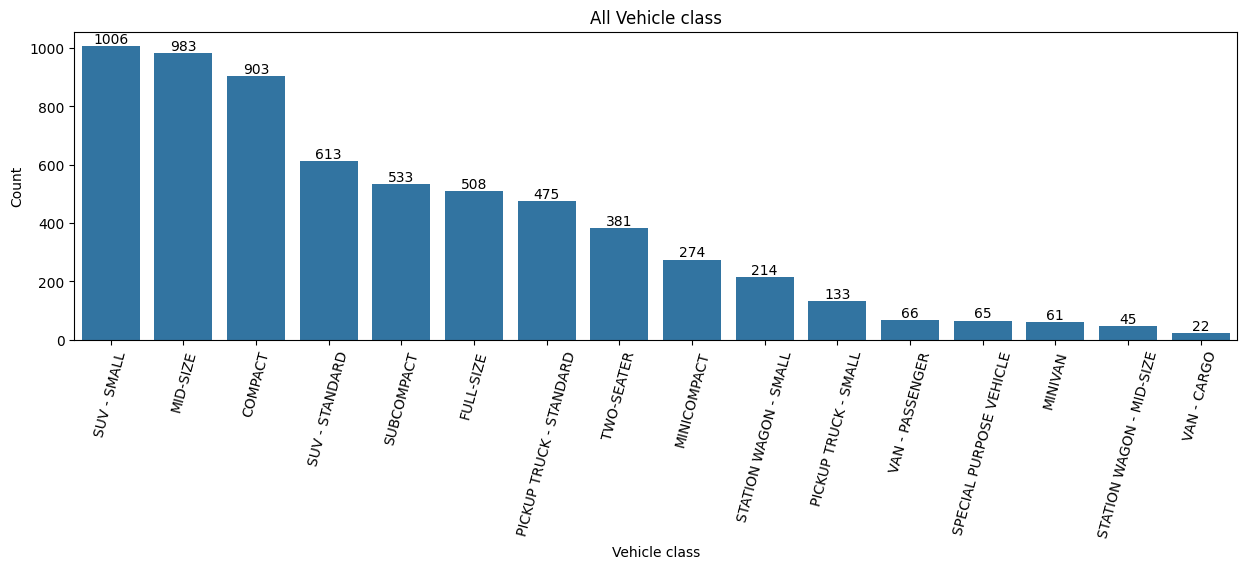

In [20]:
plt.figure(figsize=(15,4))
ax = sns.barplot(data=df_vehical_class,x="Vehicle Class",y="Count")
plt.title("All Vehicle class")
plt.xticks(rotation = 75)
plt.xlabel("Vehicle class")
plt.ylabel("Count")
plt.bar_label(ax.containers[0])
plt.show()

## **Engine size of cars**

In [21]:
print(f"we have total of {len(df["Engine Size(L)"].unique())} size of engines")
df_engine_size = df["Engine Size(L)"].value_counts().reset_index().rename(columns={"count":"Count"})
df_engine_size.head()

we have total of 51 size of engines


,Engine Size(L),Count
0,2.0,1260
1,3.0,687
2,3.6,433
3,3.5,431
4,2.5,355


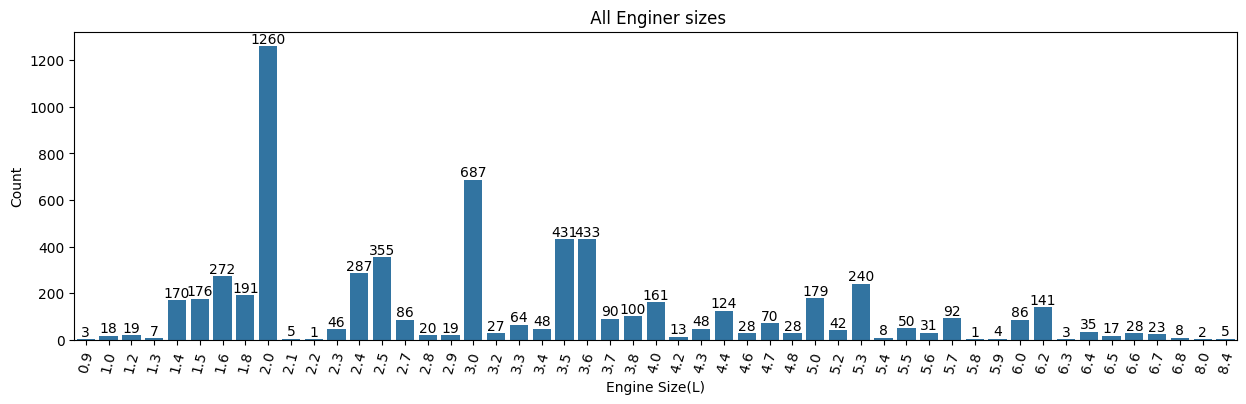

In [22]:
plt.figure(figsize=(15,4))
ax = sns.barplot(data=df_engine_size,x="Engine Size(L)",y="Count")
plt.title(" All Enginer sizes")
plt.xticks(rotation = 75)
plt.xlabel("Engine Size(L)")
plt.ylabel("Count")
plt.bar_label(ax.containers[0])
plt.show()

## **Cylinders**

In [23]:
print(f"we have total of {len(df["Cylinders"].unique())} type of cylinders")
df_cylinder = df["Cylinders"].value_counts().reset_index().rename(columns={"count":"Count"})
df_cylinder.head()

we have total of 8 type of cylinders


,Cylinders,Count
0,4,2749
1,6,2040
2,8,1202
3,12,135
4,3,88


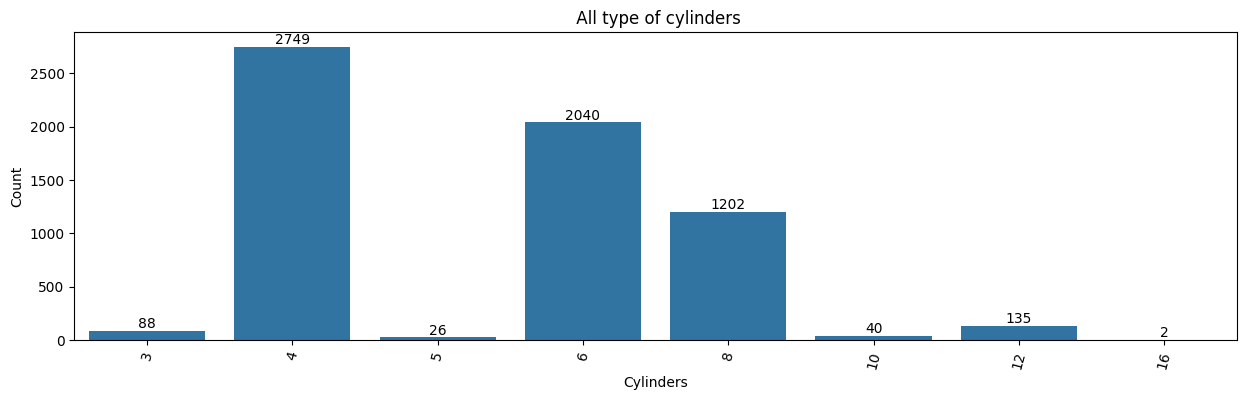

In [24]:
plt.figure(figsize=(15,4))
ax = sns.barplot(data=df_cylinder,x="Cylinders",y="Count")
plt.title(" All type of cylinders")
plt.xticks(rotation = 75)
plt.xlabel("Cylinders")
plt.ylabel("Count")
plt.bar_label(ax.containers[0])
plt.show()

## **Transmission of Cars**

In [25]:
df["Transmission"].unique()

array(['AS5', 'M6', 'AV7', 'AS6', 'AM6', 'A6', 'AM7', 'AV8', 'AS8', 'A7',
       'A8', 'M7', 'A4', 'M5', 'AV', 'A5', 'AS7', 'A9', 'AS9', 'AV6',
       'AS4', 'AM5', 'AM8', 'AM9', 'AS10', 'A10', 'AV10'], dtype=object)

In [26]:
# Here we have to map similar labels into a single label for our Transmission column.
df["Transmission"] = np.where(df["Transmission"].isin(["A4", "A5", "A6", "A7", "A8", "A9", "A10"]), "Automatic", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AM5", "AM6", "AM7", "AM8", "AM9"]), "Automated Manual", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AS4", "AS5", "AS6", "AS7", "AS8", "AS9", "AS10"]), "Automatic with Select Shift", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AV", "AV6", "AV7", "AV8", "AV10"]), "Continuously Variable", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["M5", "M6", "M7"]), "Manual", df["Transmission"])

In [27]:
print("We have total",len(df['Transmission'].unique()),"Transmissions")
df_transmission = df['Transmission'].value_counts().reset_index().rename(columns={'count':'Count'})
df_transmission

We have total 5 Transmissions


,Transmission,Count
0,Automatic with Select Shift,2722
1,Automatic,1536
2,Manual,1019
3,Automated Manual,540
4,Continuously Variable,465


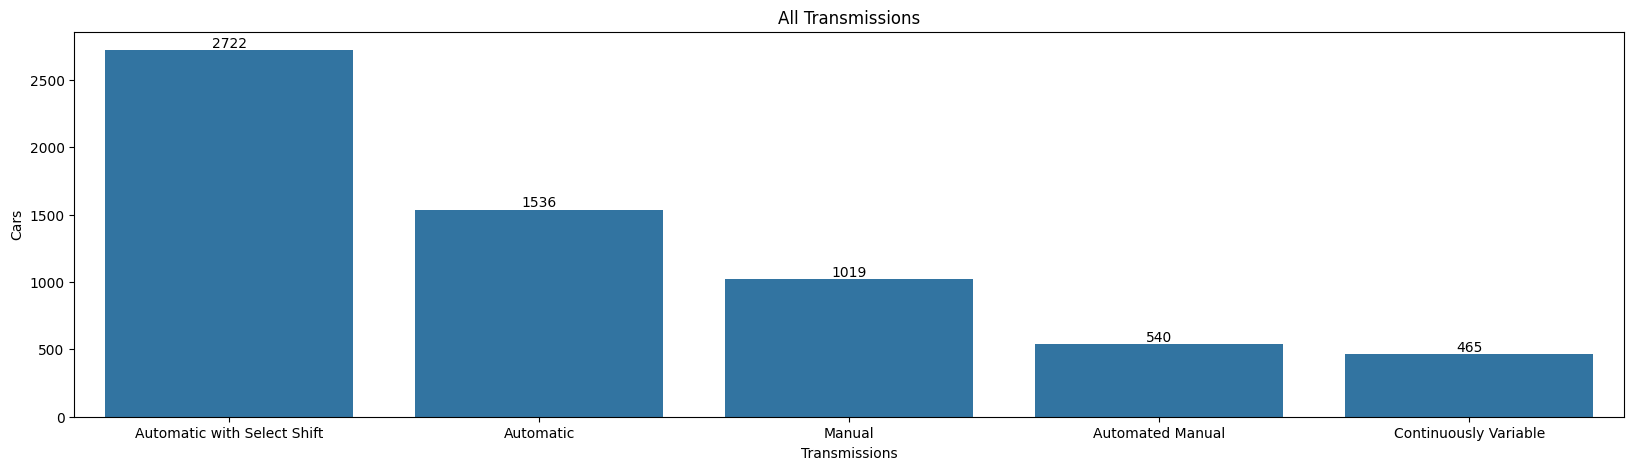

In [28]:
plt.figure(figsize=(20,5))
ax = sns.barplot(data = df_transmission, x = "Transmission",  y= "Count")
plt.title("All Transmissions")
plt.xlabel("Transmissions")
plt.ylabel("Cars")
plt.bar_label(ax.containers[0])
plt.show()

## **Fuel type**

In [29]:
df["Fuel Type"].unique()

array(['Z', 'D', 'X', 'E', 'N'], dtype=object)

In [30]:
fuel1 = {

    'Z': 'Premium gasoline',

    'D': 'Diesel',

    'X': 'Regular gasoline',

    'E': 'Ethanol (E85)',

    'N': 'Natural Gas'

}

df['Fuel Type'] = df['Fuel Type'].replace(fuel1)

In [31]:
df["Fuel Type"].unique()

array(['Premium gasoline', 'Diesel', 'Regular gasoline', 'Ethanol (E85)',
       'Natural Gas'], dtype=object)

In [32]:
print(f"we have a total of {len(df["Fuel Type"].unique())} type of fuels")
df_fuel_type = df["Fuel Type"].value_counts().reset_index().rename(columns={"count":"Count"})
df_fuel_type.head()

we have a total of 5 type of fuels


,Fuel Type,Count
0,Regular gasoline,3039
1,Premium gasoline,2765
2,Ethanol (E85),330
3,Diesel,147
4,Natural Gas,1


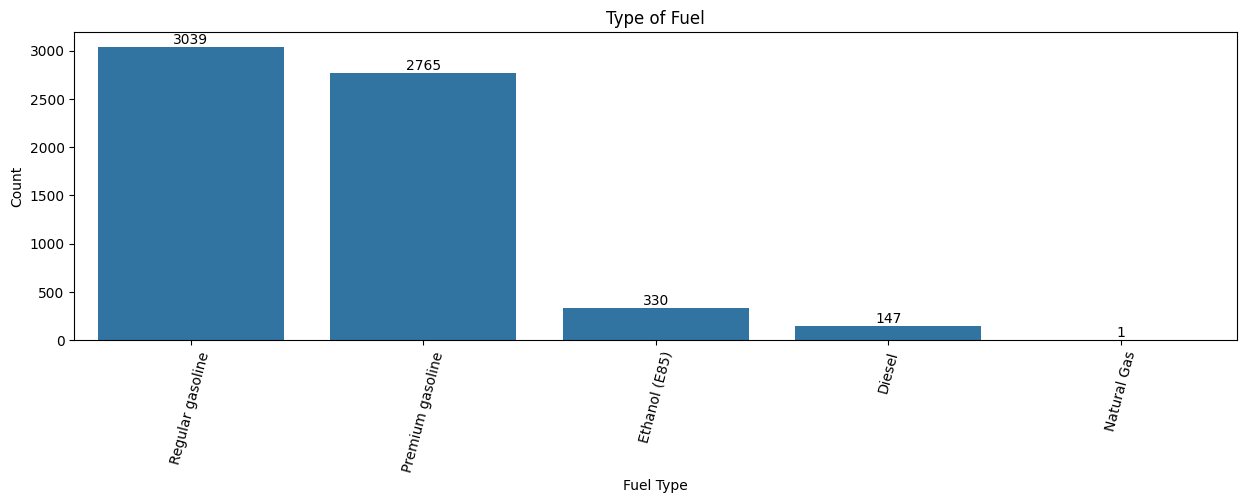

In [33]:
plt.figure(figsize=(15,4))
ax = sns.barplot(data=df_fuel_type,x="Fuel Type",y="Count")
plt.title("Type of Fuel")
plt.xticks(rotation = 75)
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.bar_label(ax.containers[0])
plt.show()

In [34]:
modes = df.mode().iloc[0]

modes

,0
Make,FORD
Model,F-150 FFV
Vehicle Class,SUV - SMALL
Engine Size(L),2.0
Cylinders,4.0
Transmission,Automatic with Select Shift
Fuel Type,Regular gasoline
Fuel Consumption City (L/100 km),11.9
Fuel Consumption Hwy (L/100 km),7.8
Fuel Consumption Comb (L/100 km),9.4


# 4. Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.

## **colinearity check**

In [35]:
df.corr(numeric_only=True)

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
Engine Size(L),1.000000,0.928843,0.834228,0.766817,0.820146,-0.762955,0.854802
Cylinders,0.928843,1.000000,0.801277,0.717647,0.781099,-0.723731,0.834687
Fuel Consumption City (L/100 km),0.834228,0.801277,1.000000,0.950811,0.994052,-0.927640,0.918756
Fuel Consumption Hwy (L/100 km),0.766817,0.717647,0.950811,1.000000,0.978607,-0.891892,0.883424
Fuel Consumption Comb (L/100 km),0.820146,0.781099,0.994052,0.978607,1.000000,-0.925801,0.916840
Fuel Consumption Comb (mpg),-0.762955,-0.723731,-0.927640,-0.891892,-0.925801,1.000000,-0.906783
CO2 Emissions(g/km),0.854802,0.834687,0.918756,0.883424,0.916840,-0.906783,1.000000


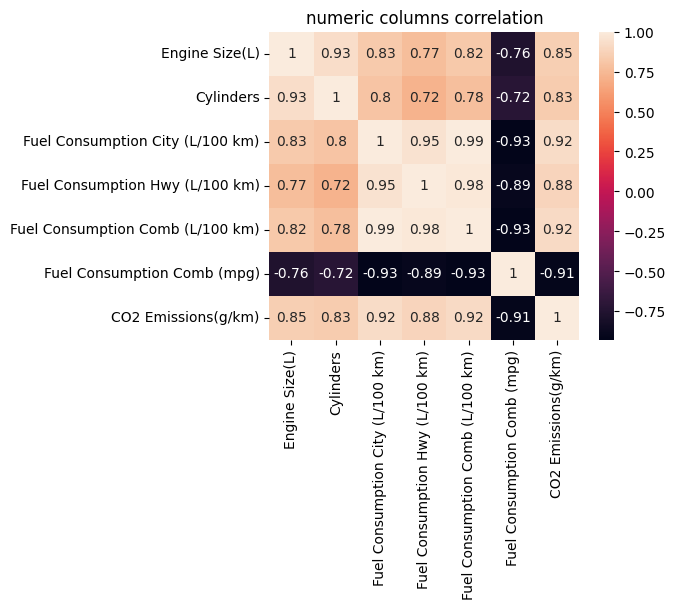

In [36]:
from matplotlib import colormaps
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("numeric columns correlation")
plt.show()

## **Checking for mulicolinearity using VIF**

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [38]:
x_vif = df.select_dtypes(include='number').drop('CO2 Emissions(g/km)',axis=1)

vif = pd.DataFrame()

vif["features"]= x_vif.columns

vif["VIF"] = [variance_inflation_factor(x_vif.values,i) for i in range(x_vif.shape[1])]

vif = vif.sort_values('VIF',ascending=False)

vif

,features,VIF
4,Fuel Consumption Comb (L/100 km),5045.257775
2,Fuel Consumption City (L/100 km),2225.278475
3,Fuel Consumption Hwy (L/100 km),623.629777
0,Engine Size(L),8.757645
1,Cylinders,7.723823
5,Fuel Consumption Comb (mpg),7.274915


**Multicollinearity Check Using VIF**

- **City** and **Hwy Fuel Consumption** have very high VIF values, indicating strong multicollinearity.
- Both features provide similar information to the combined fuel consumption feature.
- Therefore, **Fuel Consumption City** and **Fuel Consumption Hwy** were dropped to reduce redundancy.
- The remaining features were retained for further analysis.

In [39]:
df = df.drop(columns=['Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)'])

In [40]:
x_vif = df.select_dtypes(include='number').drop('CO2 Emissions(g/km)',axis=1)

vif = pd.DataFrame()

vif["features"]= x_vif.columns

vif["VIF"] = [variance_inflation_factor(x_vif.values,i) for i in range(x_vif.shape[1])]

vif = vif.sort_values('VIF',ascending=False)

vif

,features,VIF
2,Fuel Consumption Comb (L/100 km),8.978655
0,Engine Size(L),8.755712
1,Cylinders,7.349558
3,Fuel Consumption Comb (mpg),7.002739


**Multicollinearity Check Using VIF**

- VIF values are now below 10, indicating acceptable multicollinearity.
- **Fuel Consumption Comb (L/100 km)** was retained because it has a strong relationship with the target CO₂ emissions.
- **Fuel Consumption Comb (mpg)** provides similar information in a different unit, so it was dropped to avoid redundancy.

In [41]:
df = df.drop(columns=["Fuel Consumption Comb (mpg)"])

In [42]:
x_vif = df.select_dtypes(include='number').drop('CO2 Emissions(g/km)',axis=1)

vif = pd.DataFrame()

vif["features"]= x_vif.columns

vif["VIF"] = [variance_inflation_factor(x_vif.values,i) for i in range(x_vif.shape[1])]

vif = vif.sort_values('VIF',ascending=False)

vif

,features,VIF
0,Engine Size(L),8.750122
1,Cylinders,7.346929
2,Fuel Consumption Comb (L/100 km),3.080304


**Final VIF Analysis**

- All remaining features have VIF values below 10, indicating acceptable multicollinearity.
- **Engine Size(L)** has the highest VIF (8.75), followed by **Cylinders** (7.35).
- **Fuel Consumption Comb (L/100 km)** has a low VIF (3.08).
- Therefore, all three features are retained for model building.

## visulaization

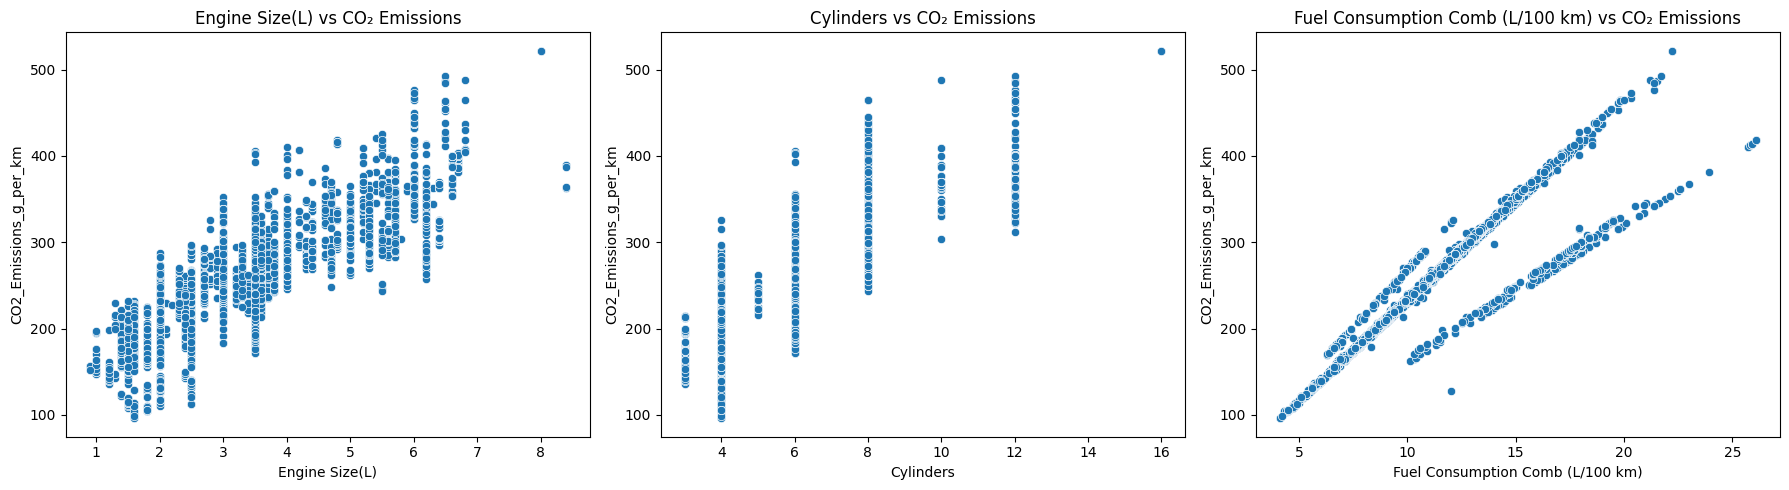

In [43]:
features = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption Comb (L/100 km)"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, features):
    sns.scatterplot(
        data=df,
        x=feature,
        y="CO2 Emissions(g/km)",
        ax=ax
    )

    ax.set_title(f"{feature} vs CO₂ Emissions")
    ax.set_xlabel(feature)
    ax.set_ylabel("CO2_Emissions_g_per_km")

plt.tight_layout()
plt.show()

# 5. Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.

## **CO2 Emission with Brand**

In [44]:
df_co2_make = df.groupby(['Make'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

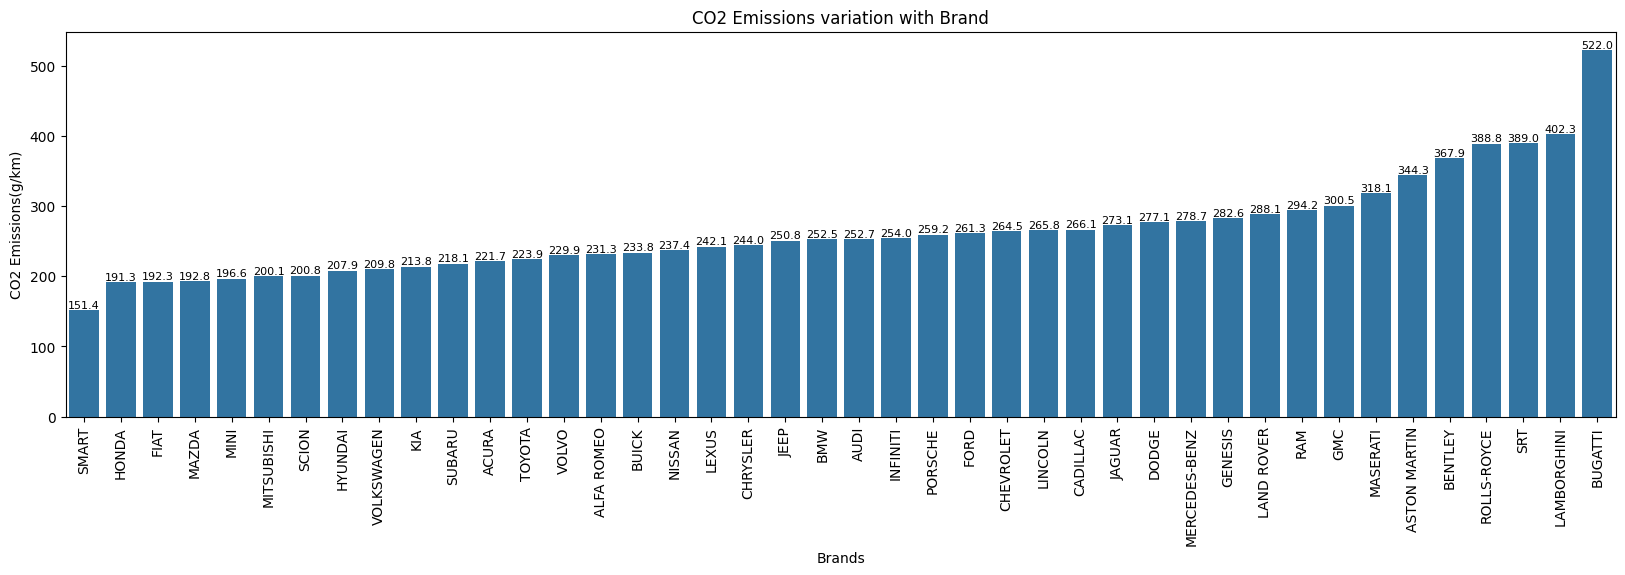

In [45]:
plt.figure(figsize=(20,5))
ax = sns.barplot(data = df_co2_make, x = "Make",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Brand")
plt.xlabel("Brands")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(ax.containers[0], fontsize=8, fmt='%.1f')
plt.show()

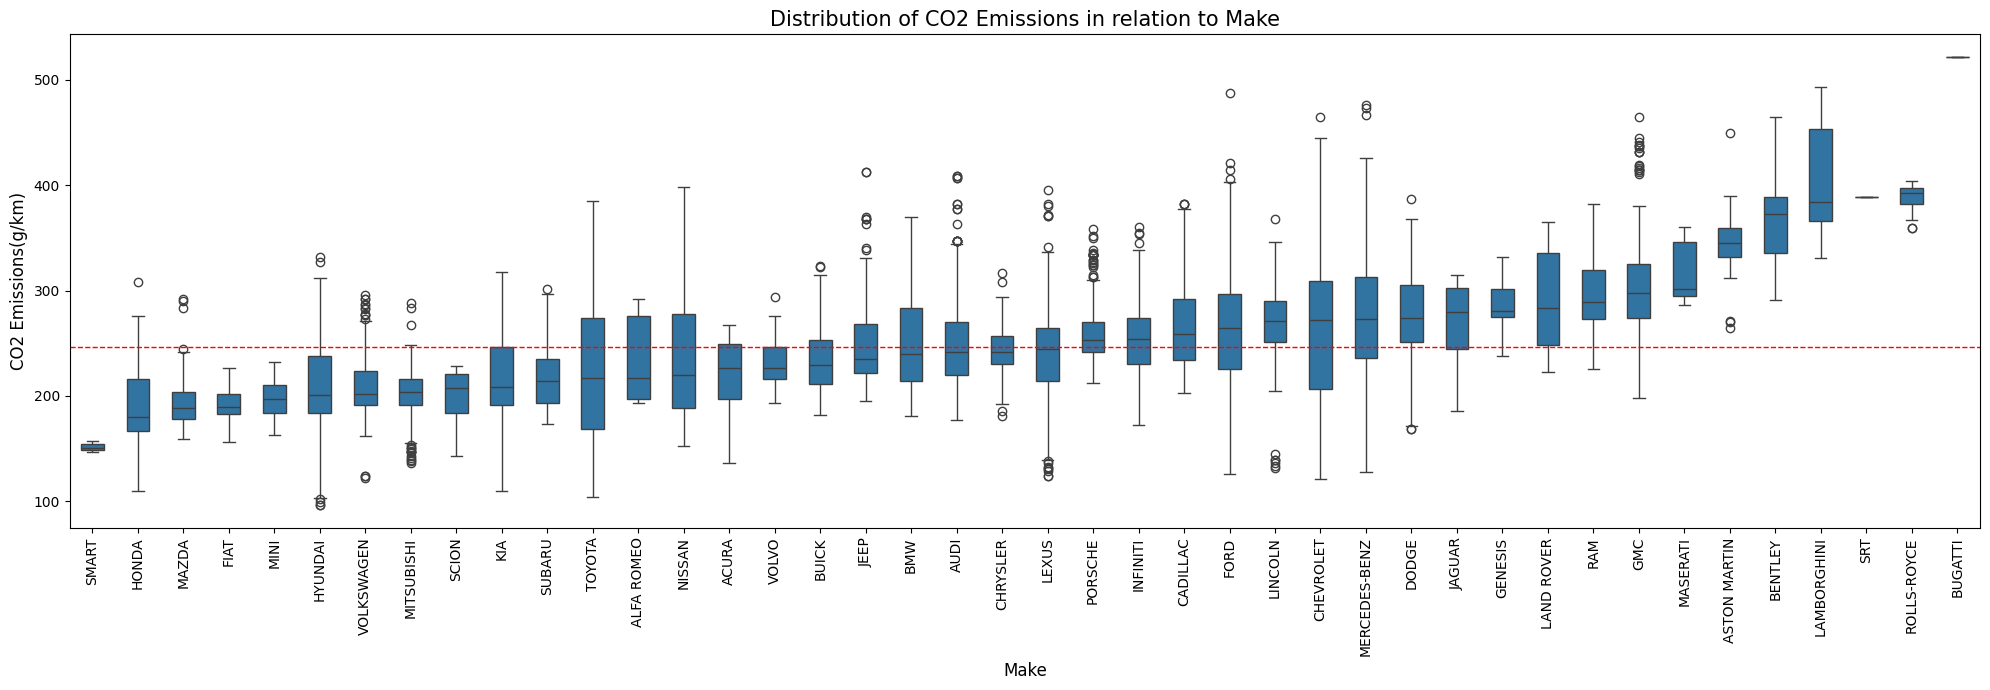

In [46]:
plt.figure(figsize=(20,7))
order = df.groupby("Make")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Make", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Make", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

## **CO2 Emissions variation with Transmission**

In [47]:
df_co2_transmission = df.groupby(['Transmission'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

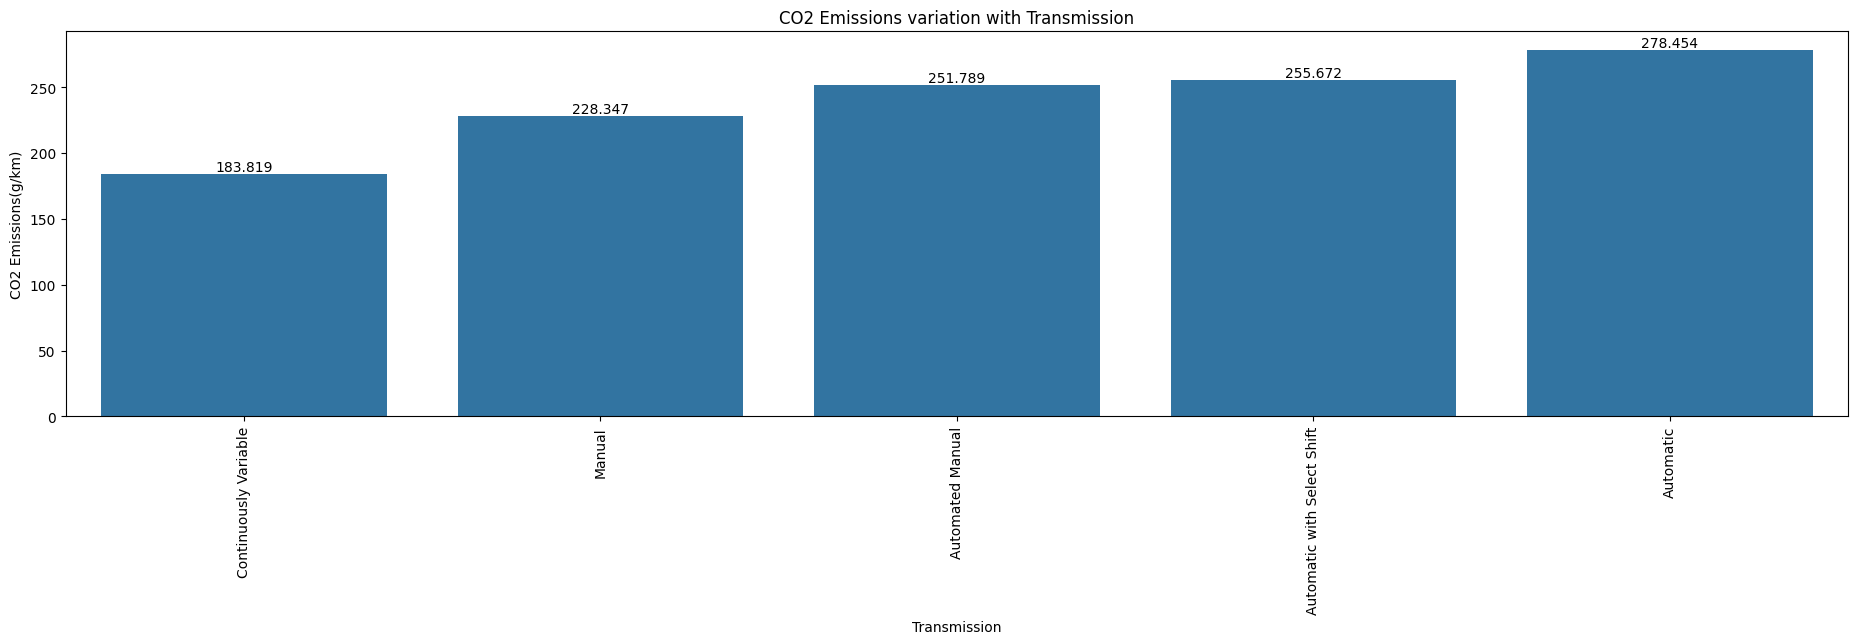

In [48]:
plt.figure(figsize=(23,5))
figure10 = sns.barplot(data = df_co2_transmission, x = "Transmission",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Transmission")
plt.xlabel("Transmission")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure10.containers[0], fontsize=10)
plt.show()

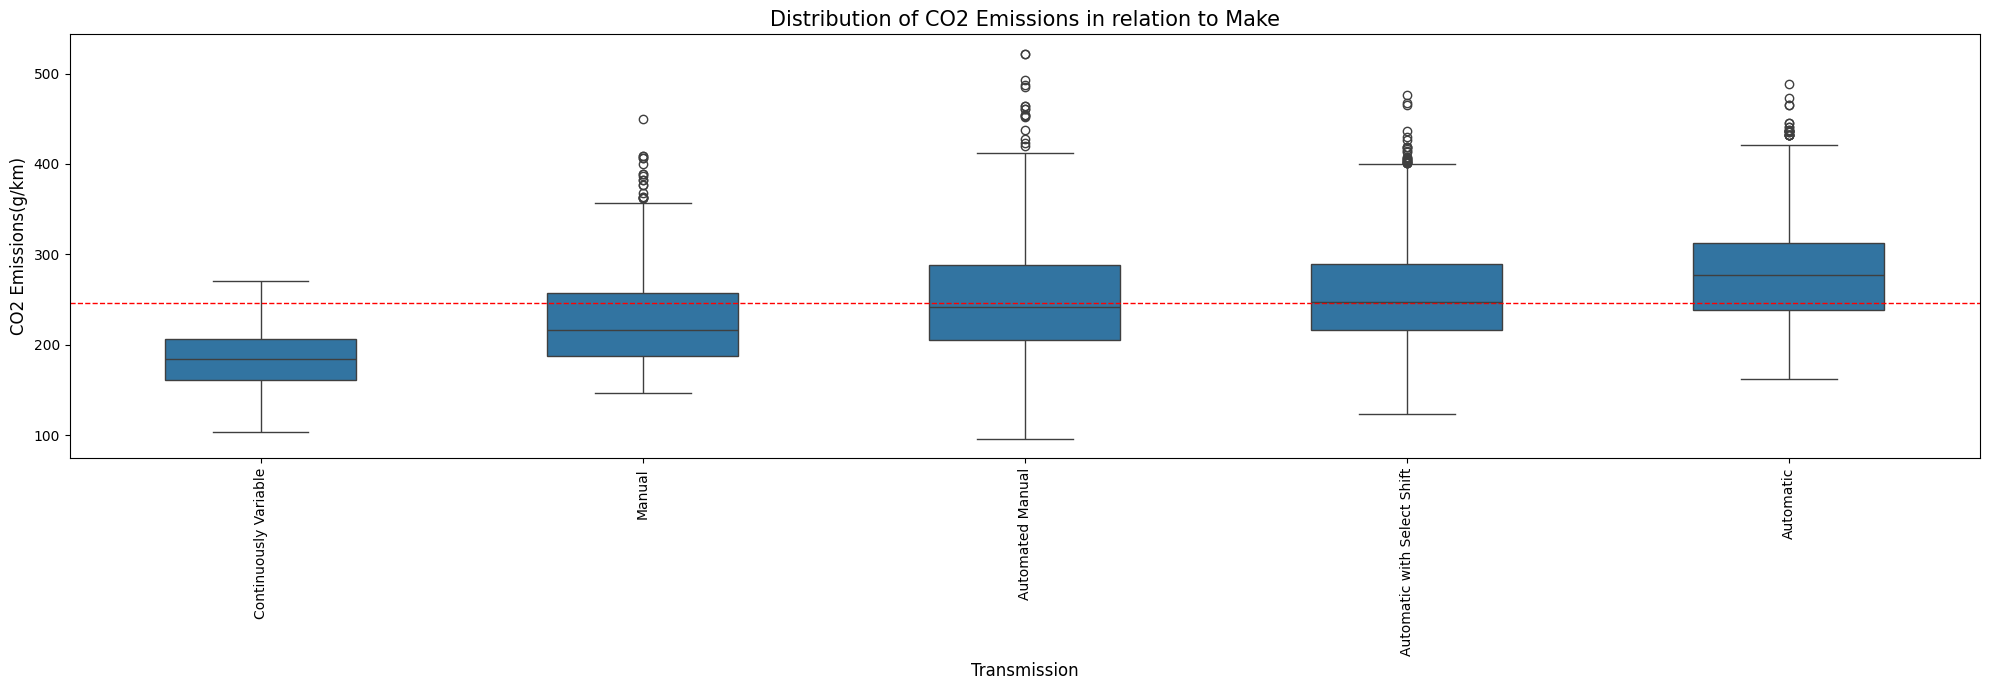

In [49]:
plt.figure(figsize=(20,7))
order = df.groupby("Transmission")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Transmission", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Transmission", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

## **CO2 Emissions variation with Vehicle Class**

In [50]:
df_co2_vehicle_class = df.groupby(['Vehicle Class'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

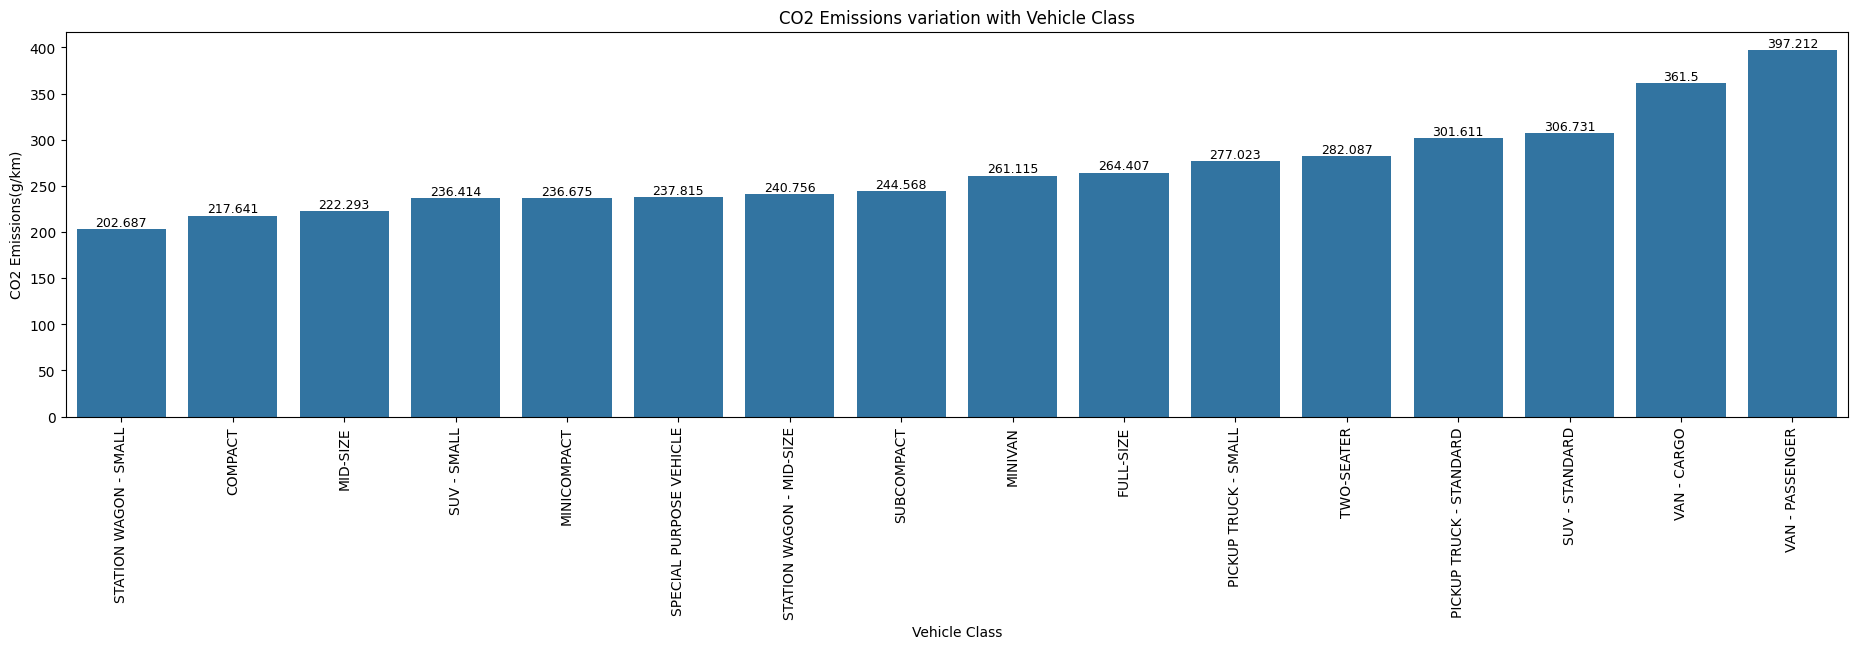

In [51]:
plt.figure(figsize=(23,5))
ax = sns.barplot(data = df_co2_vehicle_class, x = "Vehicle Class",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(ax.containers[0], fontsize=9)
plt.show()

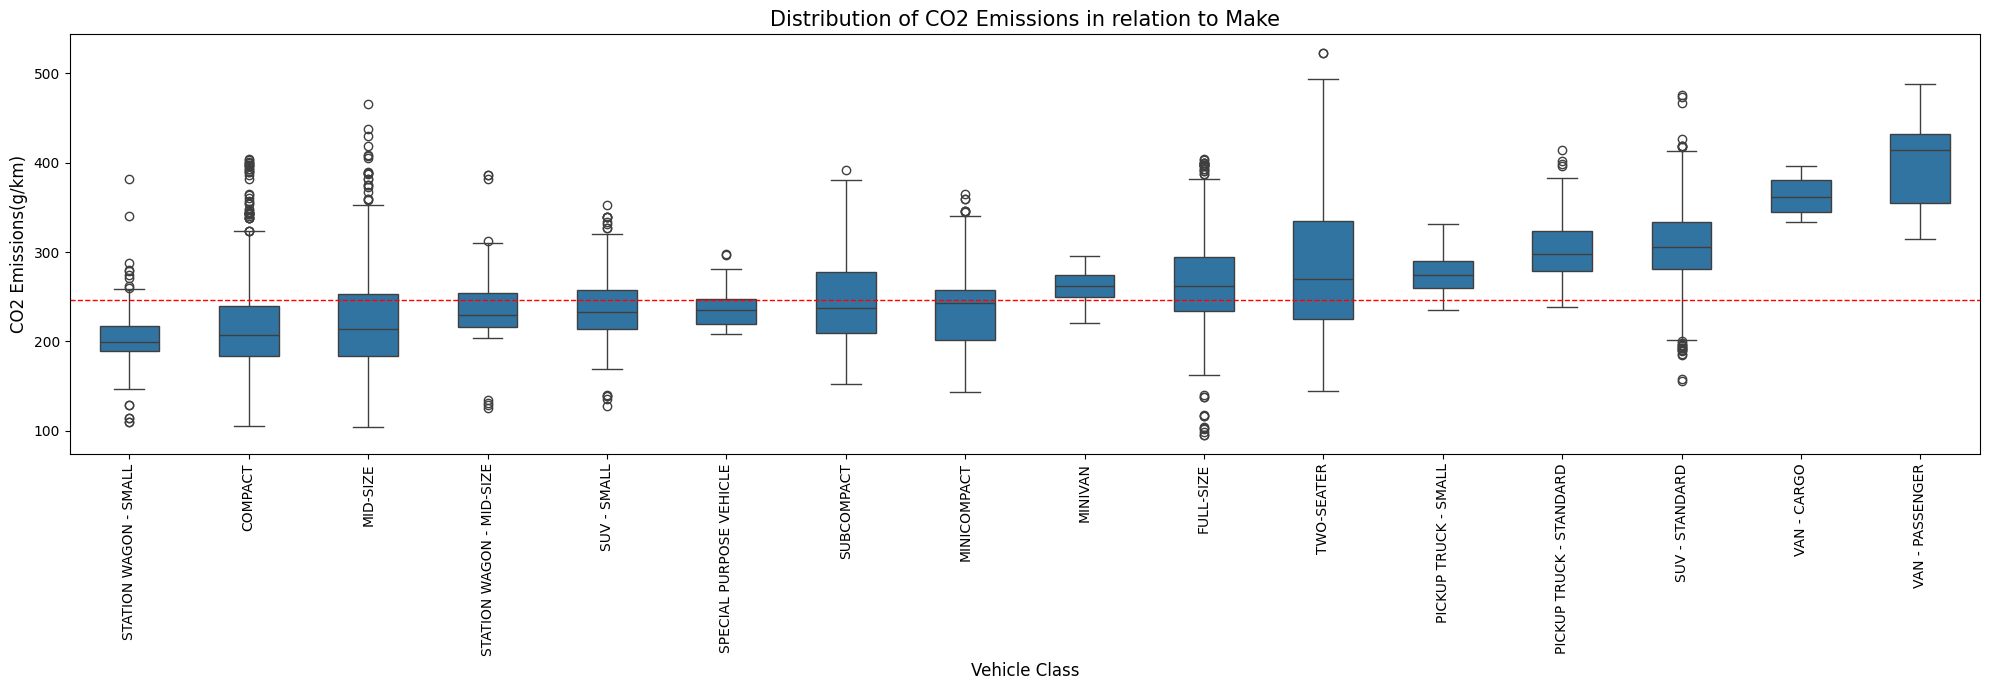

In [52]:
plt.figure(figsize=(20,7))
order = df.groupby("Vehicle Class")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Vehicle Class", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Vehicle Class", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

## **CO2 Emissions variation with Fuel Type**

In [53]:
df_co2_fuel_type = df.groupby(['Fuel Type'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

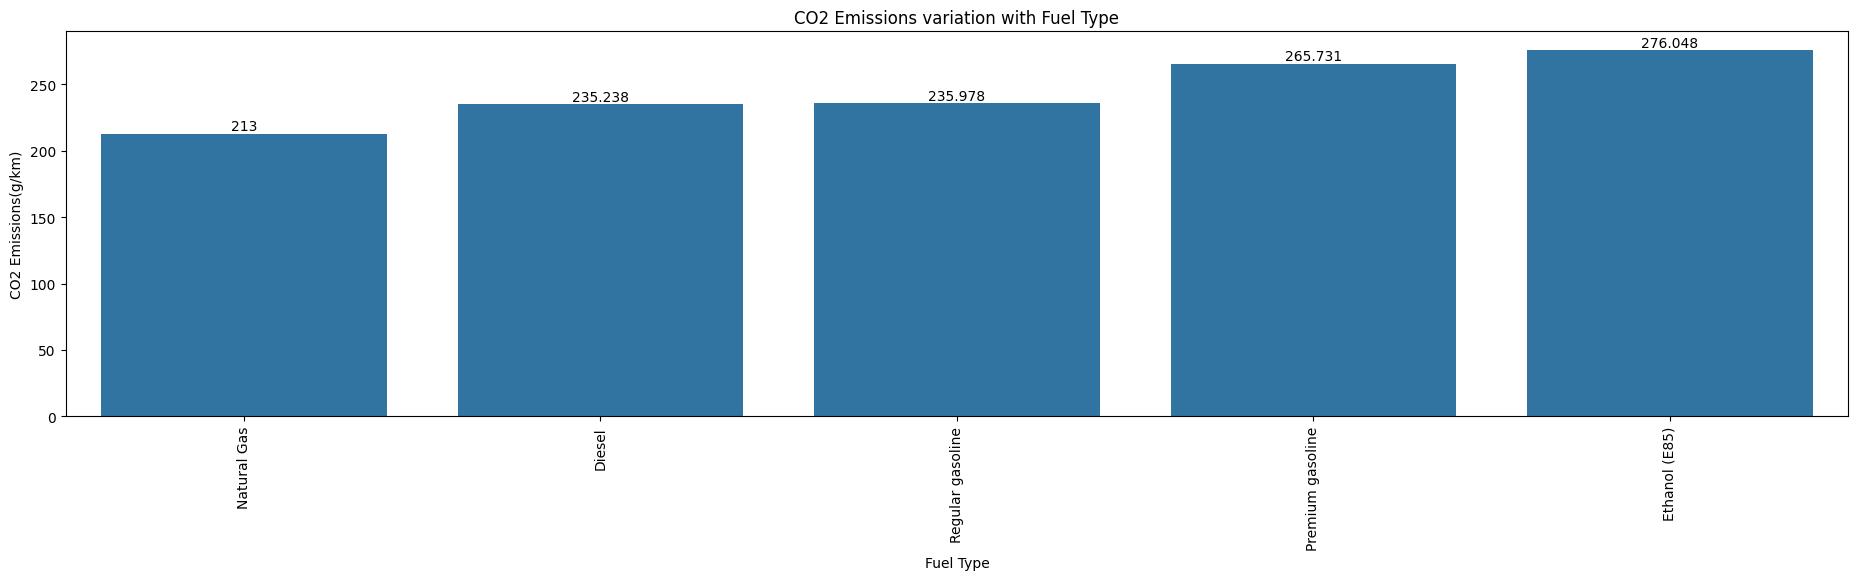

In [54]:
plt.figure(figsize=(23,5))
figure11 = sns.barplot(data = df_co2_fuel_type, x = "Fuel Type",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure11.containers[0], fontsize=10)
plt.show()

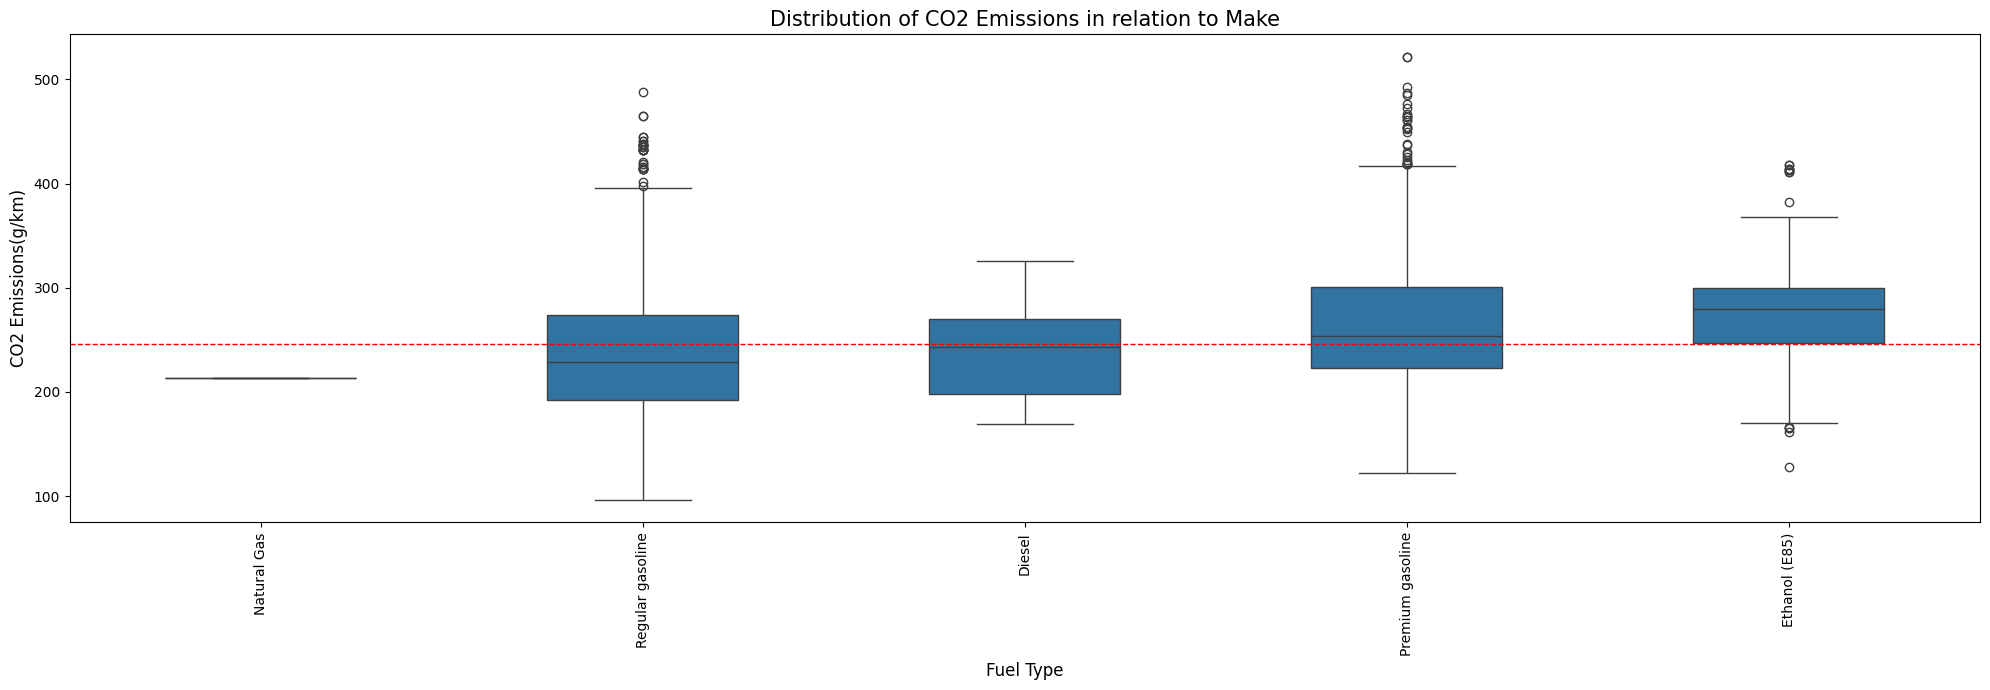

In [55]:
plt.figure(figsize=(20,7))
order = df.groupby("Fuel Type")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Fuel Type", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

# **6. Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.**

## **Outlier Detection**

In [56]:
# Defining numeric columns

numerical_columns = df.select_dtypes(exclude="object")



# Dictionary for storing outliers

outliers_summary = {}



# Outlier detection with IQR method for each column

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1



    # Finding outliers

    outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]

    outliers_summary[column] = outliers  # Storing outliers in the dictionary


    # Display outliers and total count

    #print(f"Outliers (in {column} column):\n{outliers}\n")

    print(f"Total number of outliers (in {column} column): {outliers.shape[0]}")

Total number of outliers (in Engine Size(L) column): 121
Total number of outliers (in Cylinders column): 177
Total number of outliers (in Fuel Consumption Comb (L/100 km) column): 115
Total number of outliers (in CO2 Emissions(g/km) column): 74


## Conclusion Of the EDA

1. There are total 42 types of car brand.
2. There are total 2053 unique car model. These neither can be converted into any dummy variable nor it can be used for analysis. So we can drop this column.
3. There are total 16 types of vehicle class basis on their gross vehicle weight rating (GVWR) and volume index. But there are no data available with exact GVWR or volume index value, so that we can categories the similar vehicle into a same group.
4. The 27 type of transmission has been clubbed into 5 different transmission without taking the number of clutches into account, as they does not affect CO2 emissions.
5. The 5 type of Fuel Types has been renamed so that it has some meaningful interpretation.
6. We have only one data on natural gas. So we cannot predict anything using only one data. That's why we have to drop this row.

We have to remove Natural Gass data from our data set. Because we can't predict anything by only use one record.

In [57]:
df_natural=df[df["Fuel Type"]=="Natural Gas"]
natural=df_natural.index
df_natural

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
2232,CHEVROLET,IMPALA DUAL FUEL,MID-SIZE,3.6,6,Automatic with Select Shift,Natural Gas,12.7,213


In [58]:
# We have to remove Natural Gas from our data set
for i in natural:
    df.drop(i, axis = 0,inplace = True)

In [59]:
df.reset_index(drop=True, inplace=True)

In [60]:
df[df["Fuel Type"]=="Natural Gas"]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)


In [61]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,Automatic with Select Shift,Premium gasoline,8.5,196
1,ACURA,ILX,COMPACT,2.4,4,Manual,Premium gasoline,9.6,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,Continuously Variable,Premium gasoline,5.9,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,Automatic with Select Shift,Premium gasoline,11.1,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,Automatic with Select Shift,Premium gasoline,10.6,244


In [62]:
df_check = df['Fuel Type'].value_counts().reset_index().rename(columns={'count':'Count'})
df_check

,Fuel Type,Count
0,Regular gasoline,3039
1,Premium gasoline,2765
2,Ethanol (E85),330
3,Diesel,147


To check the correlation between our data we have to remove "Model", "Make","Vehicle Class","Transmission","FuelType"

In [63]:
df.drop(['Make','Model','Vehicle Class','Transmission'],inplace=True,axis=1)


In [64]:
df_correlation = df[['Engine Size(L)','Cylinders','Fuel Consumption Comb (L/100 km)','CO2 Emissions(g/km)']]
df_correlation.head()

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


In [65]:
df_correlation.corr().T

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
Engine Size(L),1.000000,0.928843,0.820145,0.854870
Cylinders,0.928843,1.000000,0.781104,0.834739
Fuel Consumption Comb (L/100 km),0.820145,0.781104,1.000000,0.916953
CO2 Emissions(g/km),0.854870,0.834739,0.916953,1.000000


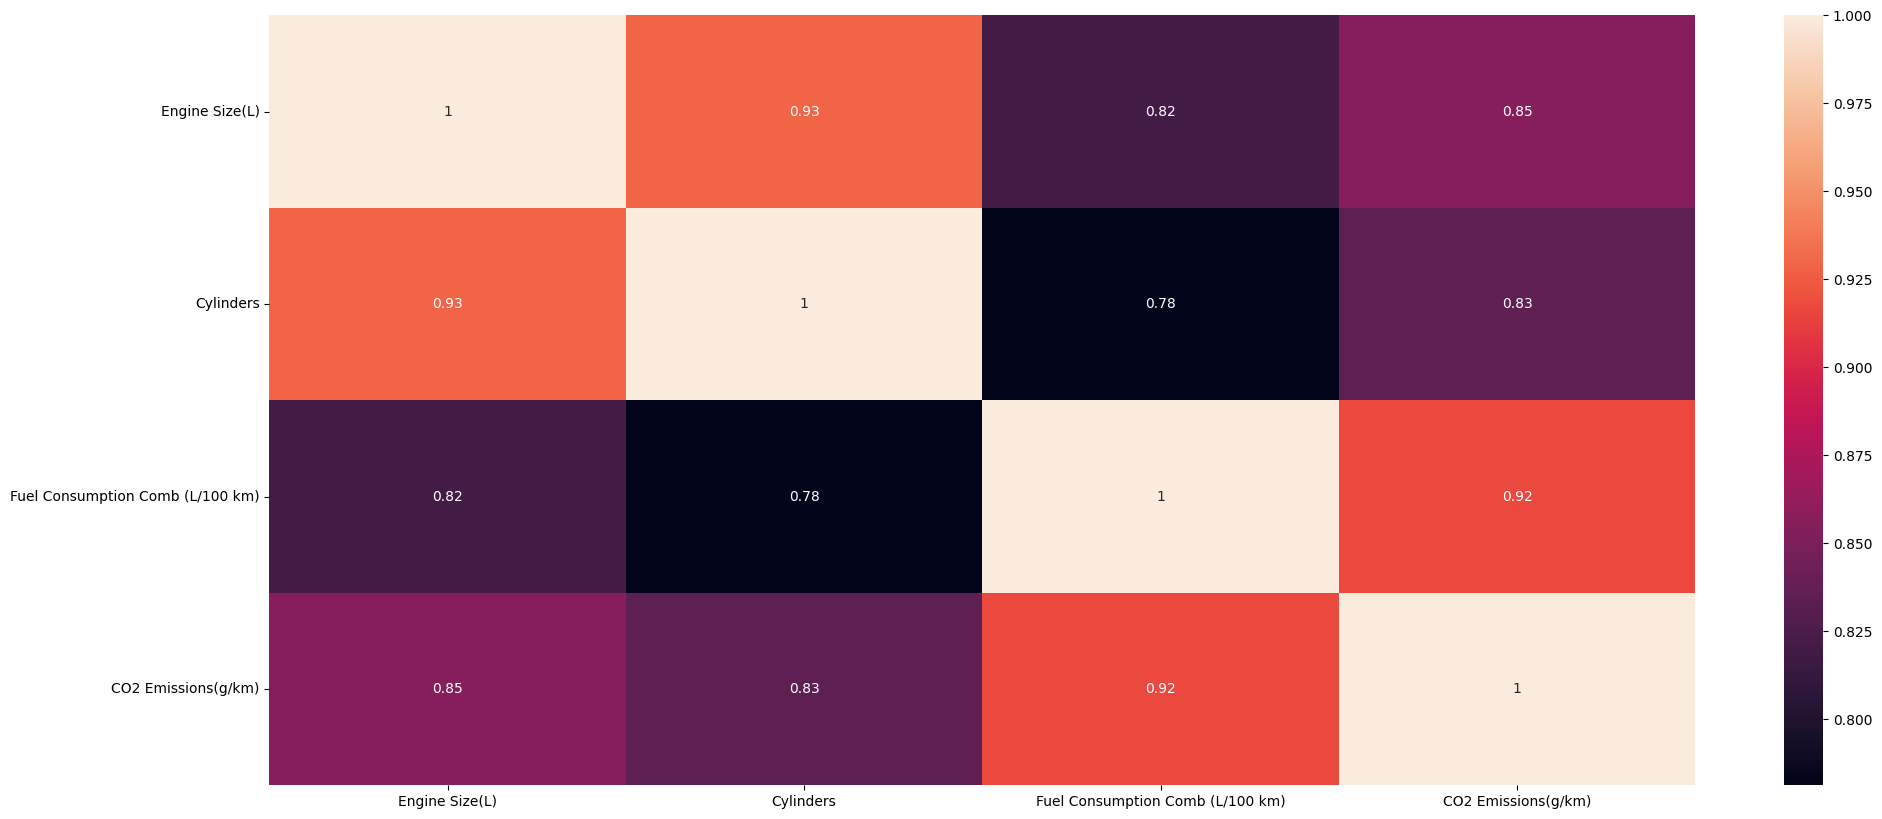

In [66]:
plt.figure(figsize = (23,10))
sns.heatmap(df_correlation.corr(), annot = True)
plt.show()

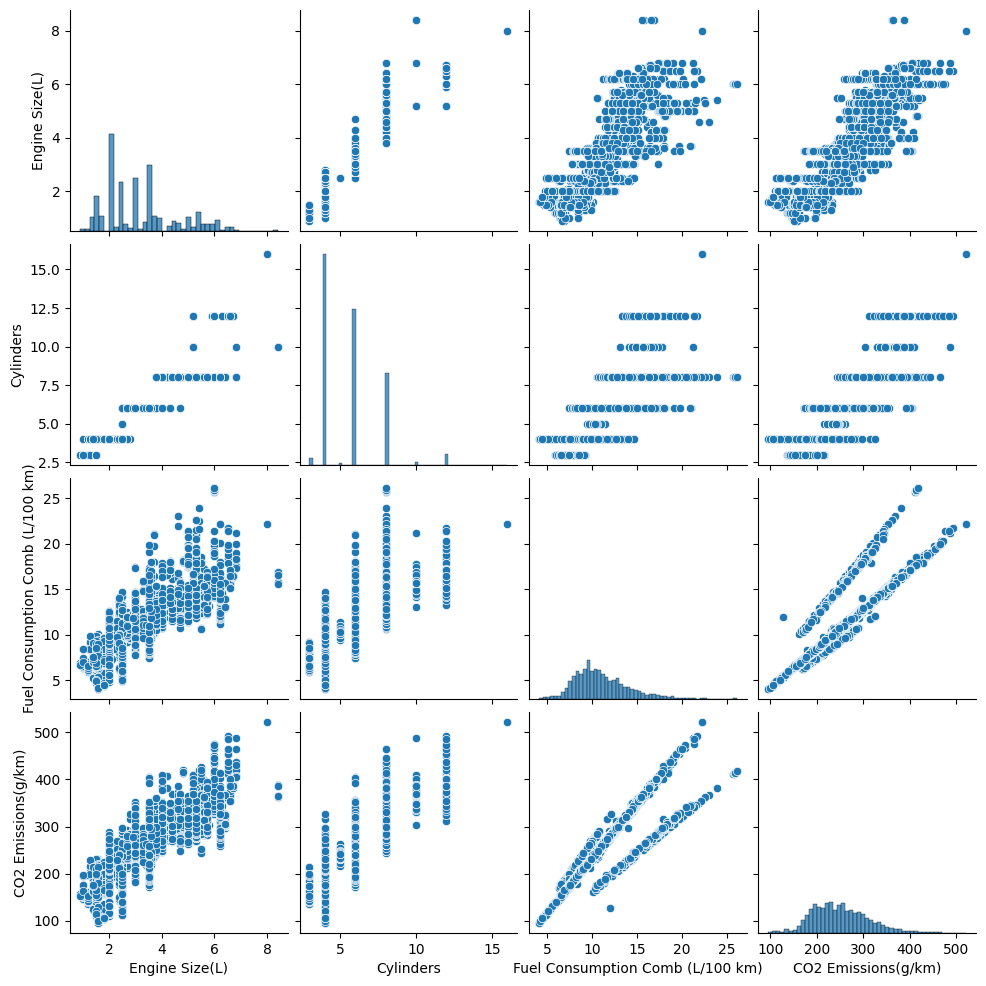

In [67]:
sns.pairplot(df_correlation)

# **7. Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.**

In [68]:
X=df.drop(columns=["CO2 Emissions(g/km)"],axis=1)
Y = df["CO2 Emissions(g/km)"]

In [69]:
print(X.shape)
print(Y.shape)

(6281, 4)
(6281,)


In [70]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

print(f"shape of x train: {X_train.shape}")
print(f"shape of x test: {X_test.shape}")
print(f"shape of y train: {y_train.shape}")
print(f"shape of y test: {y_test.shape}")

shape of x train: (5024, 4)
shape of x test: (1257, 4)
shape of y train: (5024,)
shape of y test: (1257,)


In [71]:
numerical_cols = X_train.select_dtypes(exclude="object").columns
categorical_cols = X_train.select_dtypes(include='object').columns

print(numerical_cols)
print(categorical_cols)

Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)'], dtype='object')
Index(['Fuel Type'], dtype='object')


In [72]:
preprocess = ColumnTransformer( transformers=[
    ("numeric",StandardScaler(),numerical_cols),
    ("categorical",OneHotEncoder(handle_unknown="ignore"),categorical_cols)
],remainder='drop'
)

In [73]:
X_train_scaled= preprocess.fit_transform(X_train)
X_test_scaled= preprocess.transform(X_test)

X_train_scaled

array([[-0.85436188, -0.87996829, -0.61817437, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.90601574,  1.30484055,  0.56989227, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.34611015,  1.30484055,  0.46805799, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-1.14775815, -0.87996829, -2.28146768, ...,  0.        ,
         0.        ,  1.        ],
       [-0.85436188, -0.87996829, -0.99156675, ...,  0.        ,
         0.        ,  1.        ],
       [-0.48761654, -0.87996829, -0.82184294, ...,  0.        ,
         0.        ,  1.        ]])

# **8. Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.**

In [74]:
linear_pipeline = Pipeline(
    [
        ("preprocessor",preprocess),
        ("model",LinearRegression())
    ])

In [75]:
linear_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)'], dtype='object')),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Fuel Type'], dtype='object'))])),
                ('model', LinearRegression())])

In [76]:
y_pred_train = linear_pipeline.predict(X_train)
y_pred_test = linear_pipeline.predict(X_test)

In [77]:
train_mse = mean_squared_error(y_train,y_pred_train)
train_r2_score = r2_score(y_train,y_pred_train)
test_mse = mean_squared_error(y_test,y_pred_test)
test_r2_score = r2_score(y_test,y_pred_test)

print(f"train MSE for Linear Regression: {train_mse}")
print(f"test MSE for Linear Regression: {test_mse}")
print(f"train R2 for Linear Regression: {train_r2_score}")
print(f"test R2 for Linear Regression: {test_r2_score}")

train MSE for Linear Regression: 32.60809139115663
test MSE for Linear Regression: 31.083620556102748
train R2 for Linear Regression: 0.9906267198300742
test R2 for Linear Regression: 0.9915074707632738


# **9. Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.**

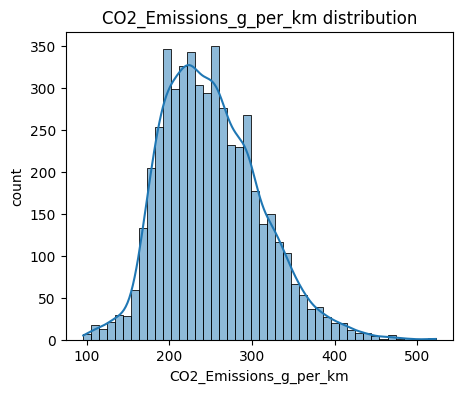

In [78]:
plt.figure(figsize=(5,4))
sns.histplot(y_train,kde=True)
plt.title("CO2_Emissions_g_per_km distribution")
plt.xlabel("CO2_Emissions_g_per_km")
plt.ylabel("count")
plt.show()


Applying Log transform on y_train and y_test

In [79]:
y_train_transformed = np.log1p(y_train)
y_test_trainsformed = np.log1p(y_test)

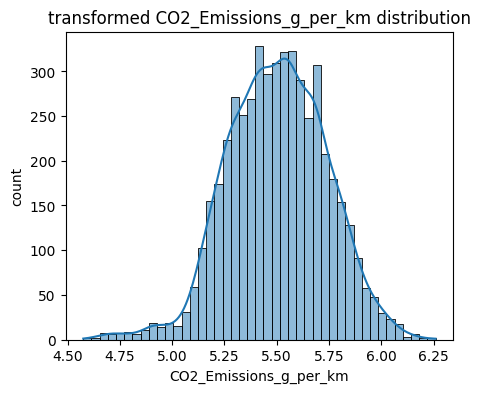

In [80]:
plt.figure(figsize=(5,4))
sns.histplot(y_train_transformed,kde=True)
plt.title("transformed CO2_Emissions_g_per_km distribution")
plt.xlabel("CO2_Emissions_g_per_km")
plt.ylabel("count")
plt.show()

In [81]:
linear_pipeline.fit(X_train,y_train_transformed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)'], dtype='object')),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Fuel Type'], dtype='object'))])),
                ('model', LinearRegression())])

In [82]:
# Predictions are currently in log(price) space
pred_train_log = linear_pipeline.predict(X_train)
pred_test_log = linear_pipeline.predict(X_test)

# Convert predictions back to original price scale
pred_train = np.expm1(pred_train_log)
pred_test = np.expm1(pred_test_log)

In [83]:
linear_train_r2 = r2_score(y_train, pred_train)
linear_test_r2 = r2_score(y_test, pred_test)

linear_mse = mean_squared_error(y_test, pred_test)


print("Train R2:", linear_train_r2)
print("Test R2 :", linear_test_r2)
print(" Test MSE",linear_mse)

Train R2: 0.9384393860686803
Test R2 : 0.939308283187634
 Test MSE 222.13856952481612


In [84]:
feature_names = (
    linear_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of features after encoding:", len(feature_names))

Number of features after encoding: 7


## **Cross Validation**

In [85]:
cv = KFold(n_splits=5, shuffle=True, random_state = 42)

cross_validate_score = cross_val_score(linear_pipeline,X_train,y_train_transformed,cv=cv,scoring='r2')

print("CV R² scores:", cross_validate_score)
print("Mean CV R²:", cross_validate_score.mean())
print("Std CV R²:", cross_validate_score.std())

CV R² scores: [0.95267336 0.96193742 0.95633266 0.96573313 0.96633253]
Mean CV R²: 0.960601819057994
Std CV R²: 0.005329941776487505


## **Building ridge pipeline**

In [86]:
Ridge_pipeline = Pipeline(steps=[
    ("preprocess",preprocess),
    ("model",Ridge())
])

In [87]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [88]:
ridge_param_grid = {"model__alpha":[0.01,0.1,1,10,100]}

ridge_grid = GridSearchCV(
    estimator=Ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

In [89]:
ridge_grid.fit(X_train, y_train_transformed)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         StandardScaler(),
                                                                         Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)'], dtype='object')),
                                                                        ('categorical',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Fuel Type'], dtype='object'))])),
                                       ('model', Ridge())]),
             n_jobs=-1, param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100]},
             return_train_score=True, scoring='neg_mean_squared_error',
             verbose=1)

In [90]:
print(
    "Best alpha:",
    ridge_grid.best_params_["model__alpha"]
)

print(
    "Best CV MSE (log scale):",
    -ridge_grid.best_score_
)

Best alpha: 0.1
Best CV MSE (log scale): 0.002188166335656314


In [91]:
best_ridge = ridge_grid.best_estimator_

ridge_train_log = best_ridge.predict(X_train)
ridge_test_log = best_ridge.predict(X_test)

#Convert back to original price scale
ridge_train_pred = np.expm1(ridge_train_log)
ridge_test_pred = np.expm1(ridge_test_log)

In [92]:
# ============================================================
# DISPLAY RIDGE COEFFICIENTS
# ============================================================

# Get the preprocessing step
preprocessor = best_ridge.named_steps["preprocess"]

# Get the Ridge model
ridge_model = best_ridge.named_steps["model"]

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Ridge coefficients
coefficients = ridge_model.coef_

# Create coefficient dataframe
ridge_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient for easy sorting
ridge_coefficients["Absolute_Coefficient"] = (
    ridge_coefficients["Coefficient"].abs()
)

# Sort by absolute coefficient
ridge_coefficients = ridge_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\n==============================")
print("RIDGE COEFFICIENTS")
print("==============================")

display(ridge_coefficients)


RIDGE COEFFICIENTS


,Feature,Coefficient,Absolute_Coefficient
4,categorical__Fuel Type_Ethanol (E85),-0.370359,0.370359
2,numeric__Fuel Consumption Comb (L/100 km),0.268113,0.268113
3,categorical__Fuel Type_Diesel,0.210933,0.210933
5,categorical__Fuel Type_Premium gasoline,0.086936,0.086936
6,categorical__Fuel Type_Regular gasoline,0.072490,0.072490
1,numeric__Cylinders,-0.010575,0.010575
0,numeric__Engine Size(L),0.002378,0.002378


In [93]:
ridge_train_r2 = r2_score(
    y_train,
    ridge_train_pred
)

ridge_test_r2 = r2_score(
    y_test,
    ridge_test_pred
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_test_pred
)

In [94]:
print("Train R2 :", ridge_train_r2)
print("Test R2  :", ridge_test_r2)
print("Test MSE :", ridge_mse)

Train R2 : 0.9384772510195578
Test R2  : 0.9393506850215305
Test MSE : 221.98337400190627


## **Buildinf a Lasso Pipeline**

In [95]:
lasso_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", Lasso())
    ]
)

In [96]:
lasso_param_grid = {
    "model__alpha": [
        0.0001,
        0.001,
        0.01,
        0.05,
        0.1,
        0.3,
        0.5,
        1,
        2,
        3,
        5,
        10,
        20,
        30,
        50,
        100
    ]
}

In [97]:
lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)


# Fit on LOG transformed target
lasso_grid.fit(X_train, y_train_transformed)


# ============================================================
# 13. BEST LASSO MODEL
# ============================================================

print("\n==============================")
print("LASSO HYPERPARAMETER TUNING")
print("==============================")

print(
    "Best alpha:",
    lasso_grid.best_params_["model__alpha"]
)

print(
    "Best CV MSE (log scale):",
    -ridge_grid.best_score_
)


# ============================================================
# 14. LASSO PREDICTIONS
# ============================================================

best_lasso = lasso_grid.best_estimator_

lasso_train_log = best_lasso.predict(X_train)
lasso_test_log = best_lasso.predict(X_test)

# Convert back to original price scale
lasso_train_pred = np.expm1(lasso_train_log)
lasso_test_pred = np.expm1(lasso_test_log)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

LASSO HYPERPARAMETER TUNING
Best alpha: 0.0001
Best CV MSE (log scale): 0.002188166335656314


In [98]:
# ============================================================
# DISPLAY LASSO COEFFICIENTS
# ============================================================

# Get the preprocessing step
preprocessor = best_lasso.named_steps["preprocess"]

# Get the Lasso model
lasso_model = best_lasso.named_steps["model"]

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Ridge coefficients
coefficients = lasso_model.coef_

# Create coefficient dataframe
lasso_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient for easy sorting
lasso_coefficients["Absolute_Coefficient"] = (
    lasso_coefficients["Coefficient"].abs()
)

# Sort by absolute coefficient
lasso_coefficients = lasso_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\n==============================")
print("Lasso COEFFICIENTS")
print("==============================")

display(lasso_coefficients)


Lasso COEFFICIENTS


,Feature,Coefficient,Absolute_Coefficient
4,categorical__Fuel Type_Ethanol (E85),-0.439461,0.439461
2,numeric__Fuel Consumption Comb (L/100 km),0.266966,0.266966
3,categorical__Fuel Type_Diesel,0.132875,0.132875
5,categorical__Fuel Type_Premium gasoline,0.013505,0.013505
1,numeric__Cylinders,-0.008539,0.008539
0,numeric__Engine Size(L),0.001191,0.001191
6,categorical__Fuel Type_Regular gasoline,-0.000269,0.000269


In [99]:
lasso_train_r2 = r2_score(
    y_train,
    lasso_train_pred
)

lasso_test_r2 = r2_score(
    y_test,
    lasso_test_pred
)

lasso_mse = mean_squared_error(
    y_test,
    lasso_test_pred
)

In [100]:
print("Train R2 :", lasso_train_r2)
print("Test R2  :", lasso_test_r2)
print("Test MSE :", lasso_mse)

Train R2 : 0.938978387933683
Test R2  : 0.9396155424352275
Test MSE : 221.01396581744842


In [101]:
coefficients = best_lasso.named_steps["model"].coef_

In [102]:
zero_coefficients = np.sum(coefficients == 0)
nonzero_coefficients = np.sum(coefficients != 0)

print("Total features    :", len(coefficients))
print("Zero coefficients :", zero_coefficients)
print("Non-zero features:", nonzero_coefficients)

Total features    : 7
Zero coefficients : 0
Non-zero features: 7


In [103]:
data = {"Model": ["Linear Regression", "Ridge Regression","Lasso Regression"], "Test R2 Score": [linear_test_r2,ridge_test_r2,lasso_test_r2],"Train R2 Score":[linear_train_r2,ridge_train_r2,lasso_train_r2]}
df=pd.DataFrame(data)
df

,Model,Test R2 Score,Train R2 Score
0,Linear Regression,0.939308,0.938439
1,Ridge Regression,0.939351,0.938477
2,Lasso Regression,0.939616,0.938978


### Final Model Evaluation

- All three models achieved a Test R² of approximately **0.94**, indicating strong predictive performance.
- The Train and Test R² scores are very close, suggesting **minimal overfitting**.
- **Lasso Regression** achieved the highest Test R² score of **0.9396** and is therefore selected as the final model.
- Ridge and Lasso provide regularization, while Lasso additionally performs feature selection by shrinking some coefficients toward zero.

# **10. Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support**

### Factors Influencing CO₂ Emissions

Based on the analysis, **Fuel Consumption, Engine Size, and the Number of Cylinders** are the key factors influencing CO₂ emissions. Vehicles with higher fuel consumption, larger engines, and more cylinders generally tend to produce higher CO₂ emissions. **Fuel Type** also contributes to differences in emission levels.

Among the models evaluated, **Lasso Regression achieved the highest Test R² score of 0.9396**, indicating that the selected features explain approximately **94% of the variation in CO₂ emissions**. The close Train and Test R² scores also indicate that the models have good generalization with no significant overfitting.

These insights can support **automotive design and policy decisions** by helping manufacturers improve fuel efficiency and optimize engine specifications. Policymakers can use such insights to develop **emission standards, fuel-efficiency regulations, and incentives for lower-emission vehicles**.
